In [1]:
import pandas as pd

In [2]:
#read my data
pd.read_csv(r"D:\current documents\Desktop\Final project\dirty_v3_path.csv")

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,54.0,Female,Healthy,86.35,127.68,28.30,94.36,1,218.60,152.82,4.85,0,0,9.15,10.35,0,3.65,8.71,ipsum,89.573837
29996,41.0,Male,Asthma,89.24,154.37,24.93,96.07,4,198.30,176.81,5.36,1,0,3.34,3.40,0,6.72,2.81,lorem,-5.864517
29997,83.0,Female,NaN,NaN,170.11,30.55,97.83,3,210.13,168.76,5.05,0,0,4.53,4.50,0,4.31,3.61,###,-30.934595
29998,41.0,Male,Diabetes,242.87,152.97,23.57,99.17,3,208.86,224.21,7.59,0,0,3.16,2.59,0,7.10,5.80,ipsum,5.085258


In [3]:
Health_care=pd.read_csv(r"D:\current documents\Desktop\Final project\dirty_v3_path.csv")

In [4]:
Health_care.drop(['random_notes','noise_col'], axis=1, inplace=True)

In [5]:
Health_care = Health_care.dropna(subset=['Medical Condition'])

In [6]:
# numerical columnsFill with median
num_cols = ['Age','Glucose','Blood Pressure']
for col in num_cols:
    Health_care[col].fillna(Health_care[col].median(), inplace=True)
#Gender → use mode

# categorical
Health_care['Gender'].fillna(Health_care['Gender'].mode()[0], inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_9532\543019867.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Health_care[col].fillna(Health_care[col].median(), inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_9532\543019867.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [7]:
#one-hot encoding
Health_care = pd.get_dummies(Health_care, columns=['Gender'], drop_first=True)

In [8]:
Health_care['Gender_Male'] = Health_care['Gender_Male'].astype(int)

In [9]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

Health_care['Medical Condition'] = le.fit_transform(Health_care['Medical Condition'])

In [18]:
Health_care.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25500 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Medical Condition  25500 non-null  int64  
 2   Glucose            25500 non-null  float64
 3   Blood Pressure     25500 non-null  float64
 4   BMI                25500 non-null  float64
 5   Oxygen Saturation  25500 non-null  float64
 6   LengthOfStay       25500 non-null  int64  
 7   Cholesterol        25500 non-null  float64
 8   Triglycerides      25500 non-null  float64
 9   HbA1c              25500 non-null  float64
 10  Smoking            25500 non-null  int64  
 11  Alcohol            25500 non-null  int64  
 12  Physical Activity  25500 non-null  float64
 13  Diet Score         25500 non-null  float64
 14  Family History     25500 non-null  int64  
 15  Stress Level       25500 non-null  float64
 16  Sleep Hours        25500 no

In [10]:
#REGRESSION MODELS -- linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import numpy as np


# Features and target
X = Health_care.drop("LengthOfStay",axis=1)
y = Health_care["LengthOfStay"]
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

# Print results
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
# Compare actual vs predicted
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head())




MAE: 1.6017874568390176
MSE: 5.663575350918846
RMSE: 2.379826748088786
R2 Score: 0.23991125632556365
       Actual  Predicted
8139        5   6.646526
13074       2   2.873127
29519       2   4.408378
3255        6   3.928231
27289       2   4.168472


In [15]:
Health_care

,Age,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,Gender_Male
0,46.0,3,137.04,135.270,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,1
1,22.0,4,71.58,113.270,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,1
2,50.0,1,95.24,138.285,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,0
3,57.0,6,110.51,130.530,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,0
4,66.0,5,95.15,178.170,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,76.0,5,97.17,138.920,25.65,93.99,3,235.65,238.26,6.43,0,0,3.14,3.46,0,6.66,6.10,0
29995,54.0,4,86.35,127.680,28.30,94.36,1,218.60,152.82,4.85,0,0,9.15,10.35,0,3.65,8.71,0
29996,41.0,1,89.24,154.370,24.93,96.07,4,198.30,176.81,5.36,1,0,3.34,3.40,0,6.72,2.81,1
29998,41.0,3,242.87,152.970,23.57,99.17,3,208.86,224.21,7.59,0,0,3.16,2.59,0,7.10,5.80,1


Randomforestregression

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.2488039215686273
MSE: 2.4658441568627447
RMSE: 1.5703006581106513
R2 Score: 0.6690676346377774


In [12]:
new_data = [[46,3,137.04,135.27,28.90,96.04,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,1]]

prediction = model.predict(new_data)

print("Predicted Length of Stay:", prediction[0])

Predicted Length of Stay: 6.03


c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


CLUSTERING


Selected Features:
['Age', 'BMI', 'Blood Pressure', 'Cholesterol']


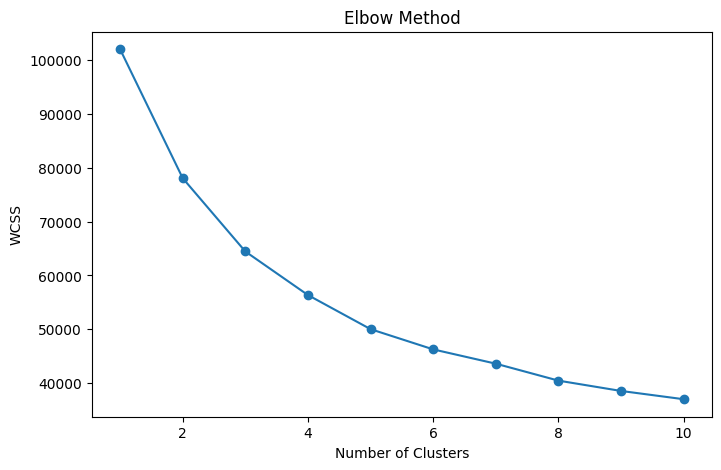


Silhouette Score: 0.21153579761757532


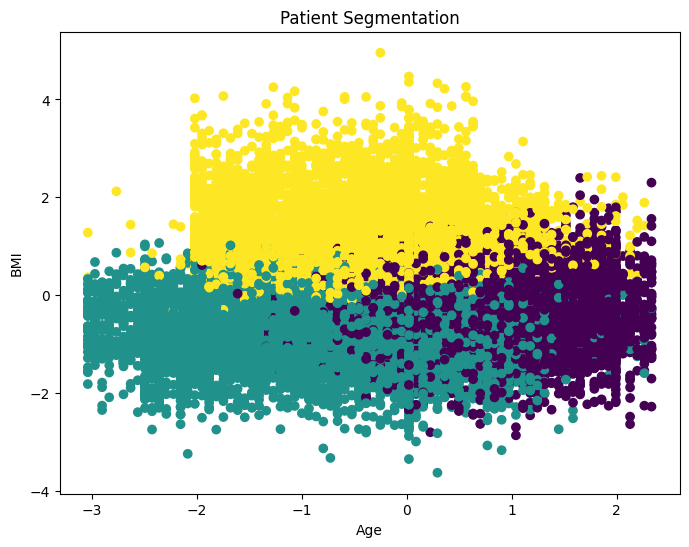


Cluster Count:
Cluster
0    9363
1    9240
2    6897
Name: count, dtype: int64

Cluster Mean Values:
               Age        BMI  Blood Pressure  Cholesterol
Cluster                                                   
0        64.606002  27.324868      155.231469   232.594665
1        47.316667  24.686109      127.814290   190.749817
2        51.129912  35.112157      136.111174   216.477680

Clustered dataset saved successfully!


In [14]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
features = [
    'Age',
    'BMI',
    'Blood Pressure',
    'Cholesterol'
]

features = [col for col in features if col in Health_care.columns]
X = Health_care[features]

print("\nSelected Features:")
print(features)

# FEATURE SCALING

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#elbow method

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Graph

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()
#k-means
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)
# Add Cluster Labels
Health_care['Cluster'] = clusters

# =========================================
# EVALUATION
# =========================================

score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", score)

# =========================================
# VISUALIZATION
# =========================================

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel(features[0])
plt.ylabel(features[1])

plt.title("Patient Segmentation")

plt.show()

# =========================================
# CLUSTER ANALYSIS
# =========================================

print("\nCluster Count:")
print(Health_care['Cluster'].value_counts())

print("\nCluster Mean Values:")
print(Health_care.groupby('Cluster')[features].mean())

# =========================================
# SAVE OUTPUT
# =========================================

Health_care.to_csv("patient_segmented_output.csv", index=False)

print("\nClustered dataset saved successfully!")

Cluster 0 → High-Risk Elderly Patients Possible Health Risks
Hypertension
Heart disease
Stroke risk
Cholesterol-related complications
Cluster 1 → Healthy / Low-Risk Patients
Better lifestyle
Lower obesity
Lower cardiac risk
Cluster 2 → Obese Middle-Aged Patients
Diabetes
Obesity
Metabolic syndrome
Future heart problems